Practical block III: Grand Challenge
Michał Binda

In [ ]:
import os
import json
import random
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

# === AUTO-DETECT NESTED ROOT ===
ROOT = Path("data/DENTEX")
subfolder = ROOT / "DENTEX"
if subfolder.exists():
    DATA_DIR = subfolder
else:
    DATA_DIR = ROOT

TRAIN_DIR = DATA_DIR / "training_data"
VAL_DIR = DATA_DIR / "validation_data"
DISEASE_DIR = DATA_DIR / "disease"
VAL_FILE = DATA_DIR / "validation_triple.json"

print(f"📂 Using dataset base: {DATA_DIR}\n")

# === 1. DIRECTORY SUMMARY ===
def explore_structure(base_dir):
    print("📁 Directory structure:\n")
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(str(base_dir), "").count(os.sep)
        indent = " " * 2 * level
        print(f"{indent}- {os.path.basename(root)}/ ({len(files)} files, {len(dirs)} dirs)")
    print("\n✅ Done.\n")

# === 2. SHOW SAMPLE IMAGES ===
def show_samples(img_dir, n=6, title=None):
    paths = list(Path(img_dir).rglob("*.jpg")) + list(Path(img_dir).rglob("*.png"))
    if not paths:
        print(f"⚠️ No images found in {img_dir}")
        return
    samples = random.sample(paths, min(n, len(paths)))
    plt.figure(figsize=(12, 6))
    for i, p in enumerate(samples):
        img = Image.open(p)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(p.stem[:15])
        plt.axis("off")
    plt.suptitle(title or img_dir.name)
    plt.tight_layout()
    plt.show()

# === 3. EXPLORE DISEASE LABELS ===
def explore_disease_pairs(disease_dir):
    input_dir = disease_dir / "input"
    label_dir = disease_dir / "label"
    inputs = sorted(list(input_dir.glob("*.jpg")))
    labels = sorted(list(label_dir.glob("*.jpg")))
    print(f"🧬 Disease samples: {len(inputs)} inputs, {len(labels)} labels.")
    if inputs and labels:
        fig, axes = plt.subplots(2, 4, figsize=(10, 5))
        for i in range(4):
            if i < len(inputs):
                axes[0, i].imshow(Image.open(inputs[i]), cmap='gray')
                axes[0, i].set_title("Input")
                axes[0, i].axis("off")
            if i < len(labels):
                axes[1, i].imshow(Image.open(labels[i]), cmap='gray')
                axes[1, i].set_title("Label")
                axes[1, i].axis("off")
        plt.tight_layout()
        plt.show()

# === 4. VALIDATION JSON SUMMARY ===
def explore_validation_json(val_file):
    if not val_file.exists():
        print("⚠️ Validation JSON not found.\n")
        return
    with open(val_file, "r") as f:
        data = json.load(f)
    print(f"✅ Loaded validation JSON with {len(data)} entries.")
    print("Example entry:\n", json.dumps(data[0], indent=2) if isinstance(data, list) else data)

# === MAIN ===
if __name__ == "__main__":
    explore_structure(DATA_DIR)

    # Display samples from each dataset type
    for subset in ["quadrant", "quadrant_enumeration", "quadrant-enumeration-disease", "unlabelled"]:
        xr_dir = TRAIN_DIR / subset / "xrays"
        if xr_dir.exists():
            show_samples(xr_dir, title=subset)

    # Disease input vs label visualization
    if DISEASE_DIR.exists():
        explore_disease_pairs(DISEASE_DIR)

    # Validation samples (if present)
    val_xrays = VAL_DIR / "quadrant_enumeration_disease" / "xrays"
    if val_xrays.exists():
        show_samples(val_xrays, title="Validation X-rays")

    explore_validation_json(VAL_FILE)

In [ ]:
import os
import glob

print("Train images:", len(glob.glob(os.path.join(TRAIN_IMAGES, "*.png"))))
print("Train labels:", len(glob.glob(os.path.join(TRAIN_LABELS, "*.txt"))))

print("Val images:", len(glob.glob(os.path.join(VAL_IMAGES, "*.png"))))
print("Val labels:", len(glob.glob(os.path.join(VAL_LABELS, "*.txt"))))

Train images: 0
Train labels: 0
Val images: 0
Val labels: 0


In [ ]:
import os

EMPTY = []
for lbl in os.listdir(TRAIN_LABELS):
    path = os.path.join(TRAIN_LABELS, lbl)
    if os.path.getsize(path) == 0:
        EMPTY.append(lbl)

print("Empty label files:", len(EMPTY))
print(EMPTY[:20])

Empty label files: 27
['train_677.txt', 'train_129.txt', 'train_666.txt', 'train_470.txt', 'train_538.txt', 'train_205.txt', 'train_416.txt', 'train_571.txt', 'train_559.txt', 'train_175.txt', 'train_410.txt', 'train_610.txt', 'train_611.txt', 'train_435.txt', 'train_346.txt', 'train_593.txt', 'train_38.txt', 'train_430.txt', 'train_357.txt', 'train_221.txt']


In [ ]:
import os
import glob
import torch
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import transforms

# ============================================================
# DEVICE
# ============================================================
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# PATHS — CHANGE TO YOURS
# ============================================================
DATA_ROOT = "/Users/michal.binda/PycharmProjects/pythonProject3/Deep_Learning_For_Medical_Image_Analysis/Projekt/data/yolo/disease_all"

TRAIN_IMAGES = os.path.join(DATA_ROOT, "images/train2017")
TRAIN_LABELS = os.path.join(DATA_ROOT, "labels/train2017")

VAL_IMAGES = os.path.join(DATA_ROOT, "images/val2017")
VAL_LABELS = os.path.join(DATA_ROOT, "labels/val2017")

IMG_SIZE = 256

# ============================================================
# DATASET
# ============================================================
class DentexYOLODataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, label_dir, img_size=256):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size

        # collect images
        all_imgs = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])

        # keep ONLY images with non-empty label files
        self.valid_imgs = []
        for img in all_imgs:
            lbl = img.replace(".png", ".txt")
            lbl_path = os.path.join(label_dir, lbl)

            if os.path.exists(lbl_path) and os.path.getsize(lbl_path) > 0:
                self.valid_imgs.append(img)

        print(f"Loaded {len(self.valid_imgs)} valid annotated images.")

    def __len__(self):
        return len(self.valid_imgs)

    def __getitem__(self, idx):
        img_name = self.valid_imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))

        # --- Load & preprocess image ---
        img = Image.open(img_path).convert("RGB")
        img = img.resize((self.img_size, self.img_size))
        img = transforms.ToTensor()(img)

        # --- Load label ---
        with open(lbl_path, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        # in theory cannot happen thanks to filtering above
        if len(lines) == 0:
            return None  

        # Use ONLY the first bounding box (simple baseline)
        cls_id, cx, cy, w, h = map(float, lines[0].split())
        cls_id = int(cls_id)

        target = torch.tensor([cx, cy, w, h, cls_id], dtype=torch.float32)

        return img, target


# ============================================================
# BASELINE MODEL (2 heads)
# ============================================================
class SimpleYOLOBaseline(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()

        # compute final size after downsampling
        self.fc_input_dim = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)

        self.box_head = nn.Linear(self.fc_input_dim, 4)      # x,y,w,h
        self.cls_head = nn.Linear(self.fc_input_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)

        box = self.box_head(x)
        cls = self.cls_head(x)  # raw logits

        return torch.cat([box, cls], dim=1)


# ============================================================
# LOSS FUNCTION
# ============================================================
def yolo_loss(pred, target):
    """
    pred: [batch, 8] => [x,y,w,h, cls_logits(4)]
    target: [batch, 5] => [x,y,w,h,class_id]
    """
    box_pred = pred[:, :4]
    box_true = target[:, :4]

    # L1 box loss
    box_loss = F.l1_loss(box_pred, box_true)

    # classification
    cls_pred = pred[:, 4:]               # shape [batch,4]
    cls_true = target[:, 4].long()       # shape [batch]

    cls_loss = F.cross_entropy(cls_pred, cls_true)

    return box_loss + cls_loss


# ============================================================
# LOAD DATA
# ============================================================
train_set = DentexYOLODataset(TRAIN_IMAGES, TRAIN_LABELS, IMG_SIZE)
val_set = DentexYOLODataset(VAL_IMAGES, VAL_LABELS, IMG_SIZE)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


# ============================================================
# TRAINING
# ============================================================
model = SimpleYOLOBaseline(num_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for img, target in train_loader:
        img = img.to(device)
        target = target.to(device)

        pred = model(img)
        loss = yolo_loss(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_loss/len(train_loader):.4f}")


# ============================================================
# VALIDATION — CLASSIFICATION ACCURACY
# ============================================================
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for img, target in val_loader:
        img = img.to(device)
        target = target.to(device)

        pred = model(img)
        cls_pred = pred[:, 4:].argmax(dim=1)
        cls_true = target[:, 4].long()

        correct += (cls_pred == cls_true).sum().item()
        total += len(cls_true)

print("Validation Accuracy:", correct / total)

Using device: mps
Loaded 678 valid annotated images.
Loaded 678 valid annotated images.
Train batches: 85
Val batches: 85
Epoch 1/5 | Train Loss: 1.2624
Epoch 2/5 | Train Loss: 1.2078
Epoch 3/5 | Train Loss: 1.1884
Epoch 4/5 | Train Loss: 1.1601
Epoch 5/5 | Train Loss: 1.1227
Validation Accuracy: 0.5471976401179941


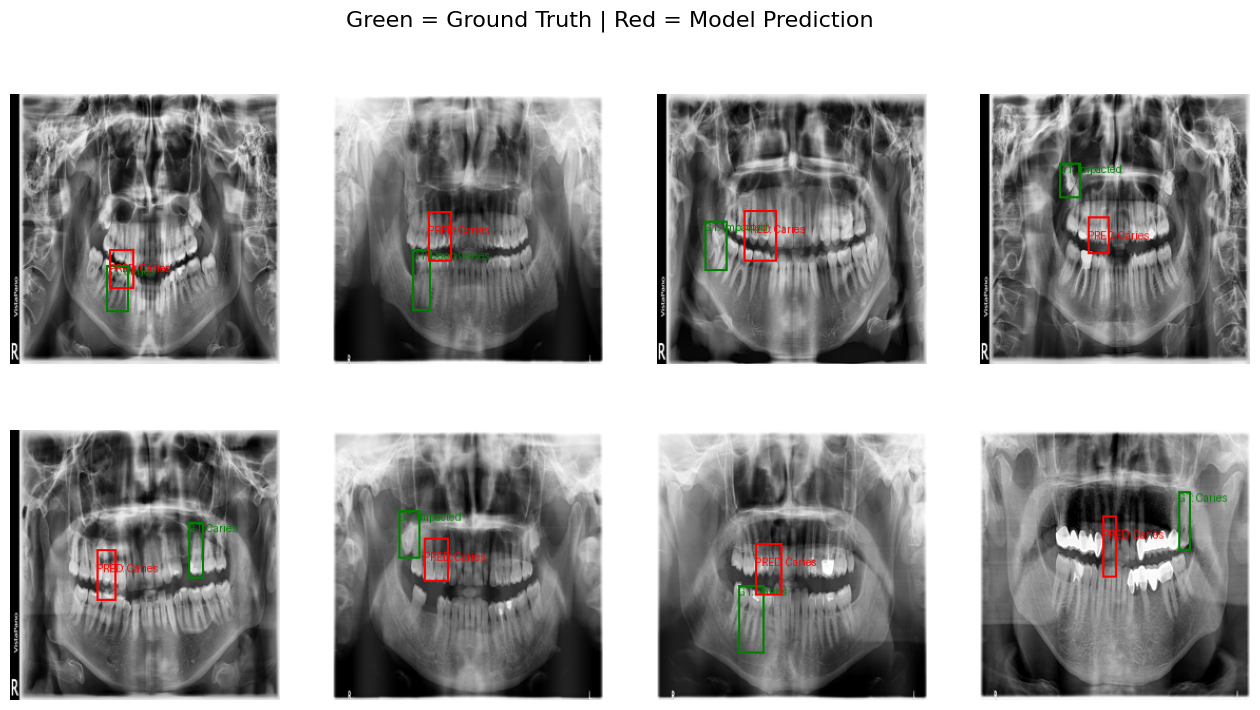

In [ ]:
import matplotlib.pyplot as plt
import random
import torchvision.transforms.functional as TF
from PIL import ImageDraw
# Class names (DENTEX disease categories)
ID2CLS = ["Impacted", "Caries", "Periapical", "Deep Caries"]

def denormalize_bbox(cx, cy, w, h, img_w, img_h):
    """Convert YOLO (cx,cy,w,h) back to pixel coordinates."""
    x1 = (cx - w/2) * img_w
    y1 = (cy - h/2) * img_h
    x2 = (cx + w/2) * img_w
    y2 = (cy + h/2) * img_h
    return int(x1), int(y1), int(x2), int(y2)

# Pick random validation samples
samples = random.sample(range(len(val_set)), 8)

plt.figure(figsize=(16, 8))

model.eval()

for idx, sample_idx in enumerate(samples):
    img, target = val_set[sample_idx]

    # Put model in eval mode and predict
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).cpu()[0]

    # Convert tensors to numpy
    img_np = TF.to_pil_image(img).copy()
    draw = ImageDraw.Draw(img_np)

    # Ground truth
    gt_cx, gt_cy, gt_w, gt_h, gt_cls = target.tolist()
    x1, y1, x2, y2 = denormalize_bbox(gt_cx, gt_cy, gt_w, gt_h, img_np.width, img_np.height)
    draw.rectangle([x1, y1, x2, y2], outline="green", width=2)
    draw.text((x1, y1), f"GT: {ID2CLS[int(gt_cls)]}", fill="green")

    # Prediction
    pred_box = pred[:4].tolist()
    pred_cls = pred[4:].argmax().item()

    px1, py1, px2, py2 = denormalize_bbox(*pred_box, img_np.width, img_np.height)
    draw.rectangle([px1, py1, px2, py2], outline="red", width=2)
    draw.text((px1, py1+12), f"PRED: {ID2CLS[pred_cls]}", fill="red")

    # Plot
    plt.subplot(2, 4, idx + 1)
    plt.imshow(img_np)
    plt.axis("off")

plt.suptitle("Green = Ground Truth | Red = Model Prediction", fontsize=16)
plt.show()